# Horse Races Results 2025–2026 — Exploratory Data Analysis

EDA of the four CSV files of the dataset. Runs standalone — no local project dependencies.

**Sections:**
1. Setup & data loading
2. Races — hippodromes, disciplines, calendar, field sizes
3. Runners — horses, jockeys, trainers, scratch rate
4. Odds — distribution, morning vs final, bookmaker margin
5. Race results — favourite analysis, odds drift, market calibration
6. Form (musique) — recent form vs win rate

## 1. Setup & Data Loading

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})
BLUE, ORANGE, GREEN, RED, GREY = '#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8c8c8c'

# ── Paths: local or Kaggle ───────────────────────────────────────────────────
if Path('/kaggle/input').exists():
    DATA = Path('/kaggle/input/horse-races-results-2025-2026')
else:
    DATA = Path('../data/kaggle')

races        = pd.read_csv(DATA / 'races.csv', parse_dates=['race_datetime'])
runners      = pd.read_csv(DATA / 'runners.csv')
odds         = pd.read_csv(DATA / 'odds.csv')
race_results = pd.read_csv(DATA / 'race_results.csv', parse_dates=['race_datetime'])

print('Loaded:')
print(f'  races.csv        {len(races):>7,} rows')
print(f'  runners.csv      {len(runners):>7,} rows')
print(f'  odds.csv         {len(odds):>7,} rows')
print(f'  race_results.csv {len(race_results):>7,} rows')
print(f'\nDate range: {races.date.min()} -> {races.date.max()}')

Loaded:
  races.csv          4,108 rows
  runners.csv       50,818 rows
  odds.csv          99,348 rows
  race_results.csv  38,314 rows

Date range: 20250909 -> 20260311


## 2. Races

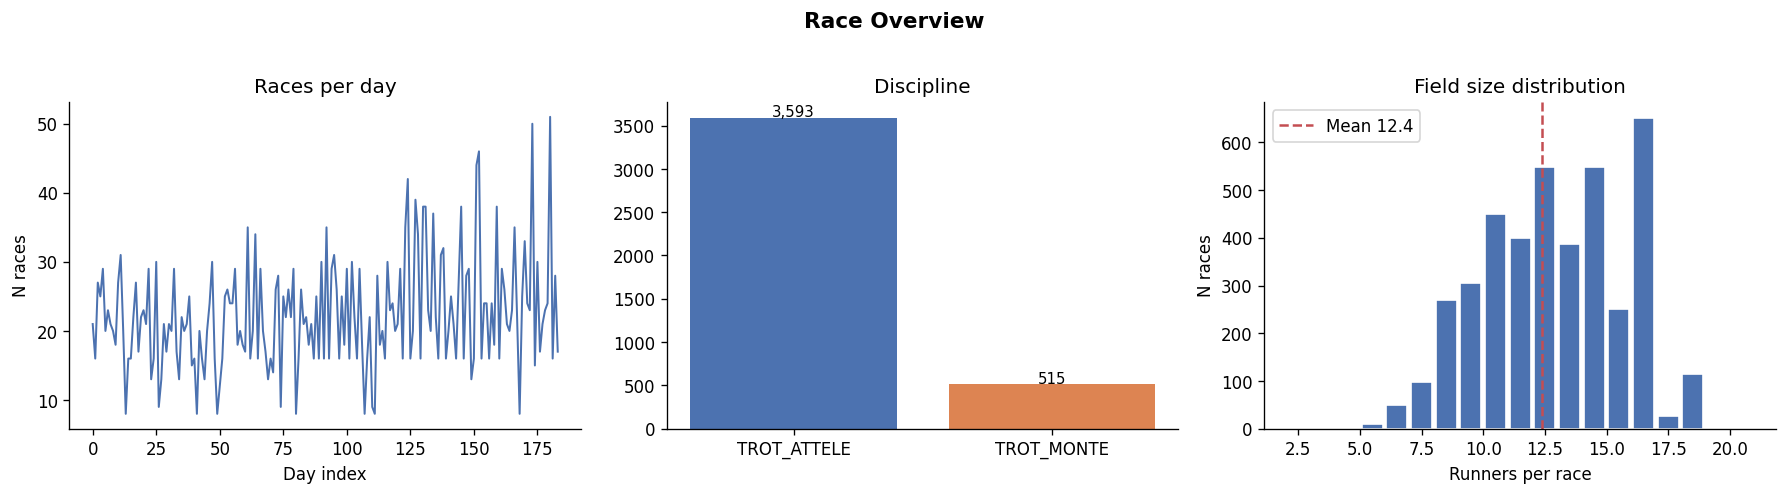

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Races per day
daily = races.groupby('date').size()
axes[0].plot(range(len(daily)), daily.values, color=BLUE, linewidth=1.2)
axes[0].set_title('Races per day')
axes[0].set_xlabel('Day index')
axes[0].set_ylabel('N races')

# Discipline
disc = races['discipline'].value_counts()
axes[1].bar(disc.index, disc.values, color=[BLUE, ORANGE])
axes[1].set_title('Discipline')
for i, v in enumerate(disc.values):
    axes[1].text(i, v + 10, f'{v:,}', ha='center', fontsize=9)

# Field size distribution
axes[2].hist(races['field_size'].dropna(), bins=range(2, 22), color=BLUE, edgecolor='white', rwidth=0.85)
axes[2].set_title('Field size distribution')
axes[2].set_xlabel('Runners per race')
axes[2].set_ylabel('N races')
axes[2].axvline(races['field_size'].mean(), color=RED, linestyle='--', label=f'Mean {races["field_size"].mean():.1f}')
axes[2].legend()

plt.suptitle('Race Overview', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

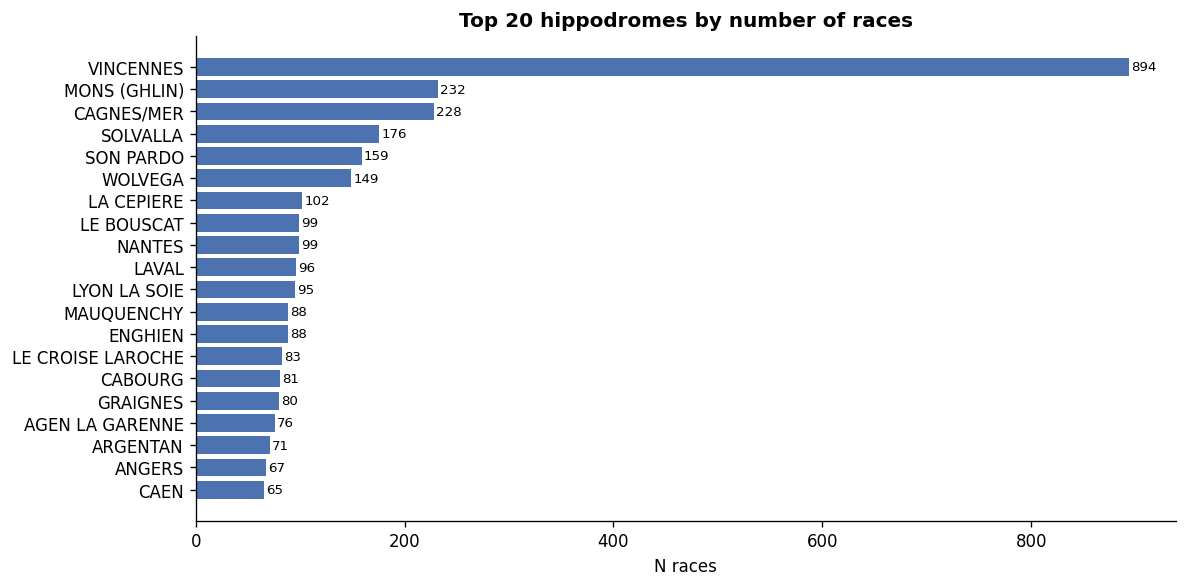

In [3]:
# Top 20 hippodromes by number of races
top_hippos = races['hippodrome'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(top_hippos.index[::-1], top_hippos.values[::-1], color=BLUE)
for bar, val in zip(bars, top_hippos.values[::-1]):
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height() / 2,
            str(val), va='center', fontsize=8)
ax.set_title('Top 20 hippodromes by number of races', fontweight='bold')
ax.set_xlabel('N races')
plt.tight_layout()
plt.show()

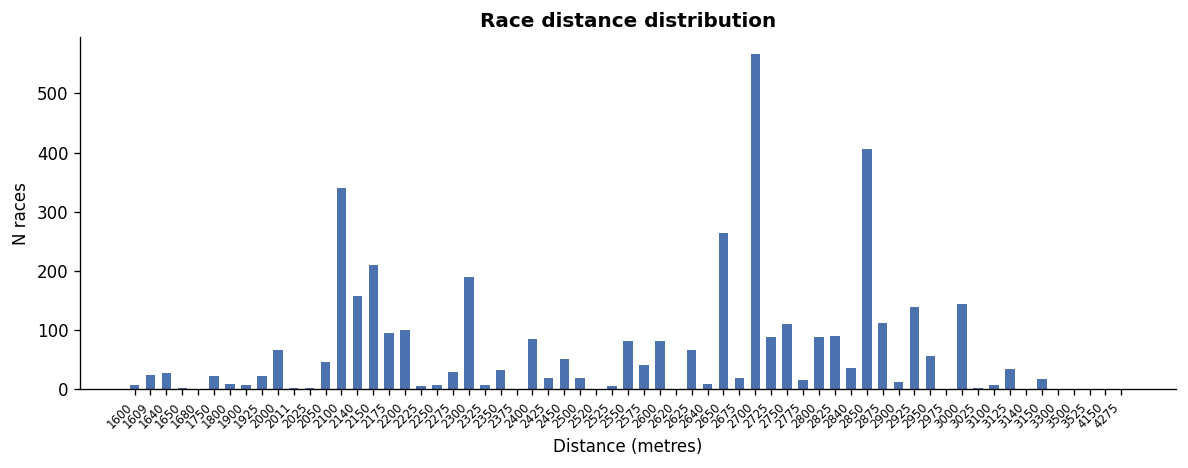

count    4108.000000
mean     2535.779698
std       338.318093
min      1600.000000
25%      2175.000000
50%      2650.000000
75%      2825.000000
max      4275.000000


In [4]:
# Distance distribution
fig, ax = plt.subplots(figsize=(10, 4))
dist_counts = races['distance_metres'].value_counts().sort_index()
ax.bar(dist_counts.index.astype(str), dist_counts.values, color=BLUE, width=0.6)
ax.set_title('Race distance distribution', fontweight='bold')
ax.set_xlabel('Distance (metres)')
ax.set_ylabel('N races')
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.tight_layout()
plt.show()

print(races['distance_metres'].describe().to_string())

## 3. Runners

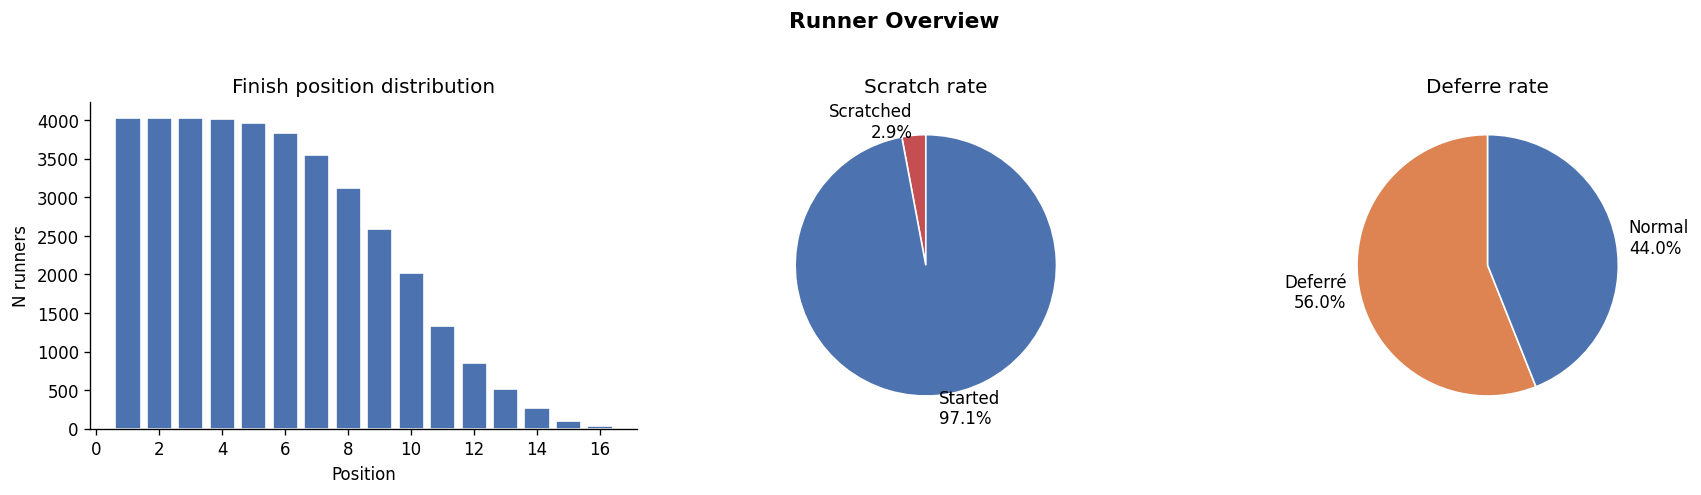

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Finish position distribution
resolved = runners[runners['finish_position'].notna()]
pos_counts = resolved['finish_position'].value_counts().sort_index().head(16)
axes[0].bar(pos_counts.index.astype(int), pos_counts.values, color=BLUE, edgecolor='white')
axes[0].set_title('Finish position distribution')
axes[0].set_xlabel('Position')
axes[0].set_ylabel('N runners')

# Scratch rate
scratch_rate = runners['scratch'].mean()
axes[1].pie([scratch_rate, 1 - scratch_rate],
            labels=[f'Scratched\n{scratch_rate:.1%}', f'Started\n{1-scratch_rate:.1%}'],
            colors=[RED, BLUE], startangle=90, wedgeprops={'edgecolor': 'white'})
axes[1].set_title('Scratch rate')

# Deferre rate
deferre_rate = runners['deferre'].fillna(False).mean()
axes[2].pie([deferre_rate, 1 - deferre_rate],
            labels=[f'Deferré\n{deferre_rate:.1%}', f'Normal\n{1-deferre_rate:.1%}'],
            colors=[ORANGE, BLUE], startangle=90, wedgeprops={'edgecolor': 'white'})
axes[2].set_title('Deferre rate')

plt.suptitle('Runner Overview', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

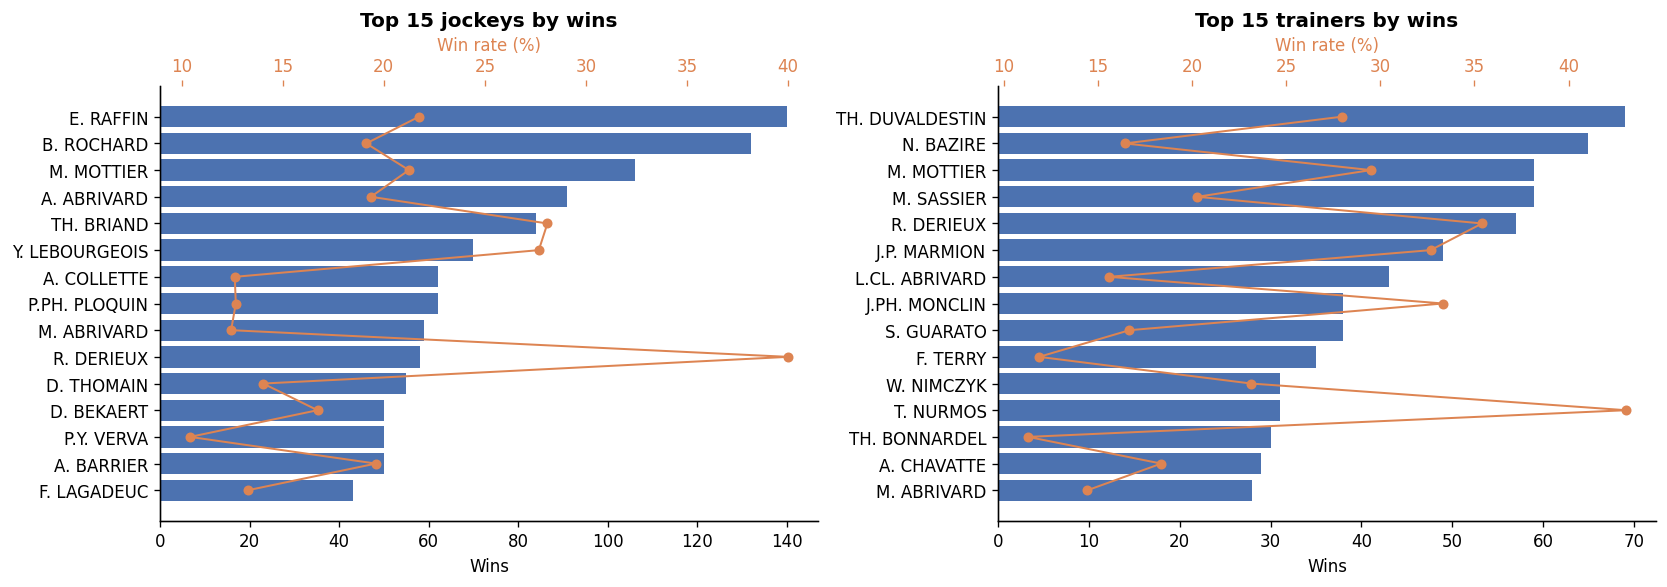

In [6]:
# Top jockeys and trainers by win count
wins = resolved[resolved['finish_position'] == 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title in [
    (axes[0], 'jockey_name', 'Top 15 jockeys by wins'),
    (axes[1], 'trainer_name', 'Top 15 trainers by wins'),
]:
    top = wins[col].value_counts().head(15)
    starts = resolved[col].value_counts()
    win_rate = (top / starts.reindex(top.index)).fillna(0)

    bars = ax.barh(top.index[::-1], top.values[::-1], color=BLUE)
    ax2 = ax.twiny()
    ax2.plot(win_rate.values[::-1] * 100, range(len(top)), 'o-',
             color=ORANGE, markersize=5, linewidth=1.2, label='Win rate %')
    ax2.set_xlabel('Win rate (%)', color=ORANGE)
    ax2.tick_params(axis='x', colors=ORANGE)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Wins')

plt.tight_layout()
plt.show()

## 4. Odds

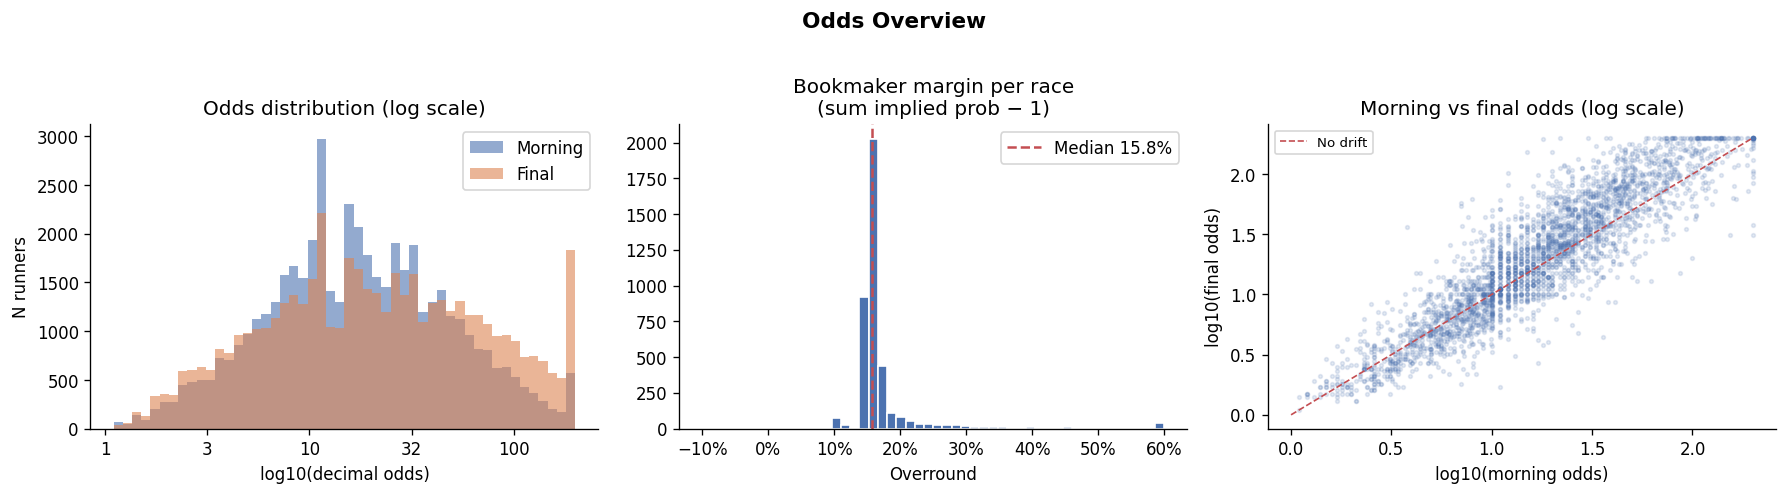

Median bookmaker margin: 15.8%
Median morning odds:     17.0
Median final odds:       20.0


In [7]:
morning = odds[odds['odds_type'] == 'morning']
final   = odds[odds['odds_type'] == 'final']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Log-scale odds distribution
for ax, df, label, color in [
    (axes[0], morning, 'Morning', BLUE),
    (axes[0], final,   'Final',   ORANGE),
]:
    ax.hist(np.log10(df['decimal_odds'].clip(1, 200)), bins=50,
            alpha=0.6, color=color, label=label, edgecolor='none')
axes[0].set_title('Odds distribution (log scale)')
axes[0].set_xlabel('log10(decimal odds)')
axes[0].set_ylabel('N runners')
axes[0].legend()
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{10**x:.0f}'))

# Bookmaker margin per race
margin = morning.groupby('race_id')['implied_prob'].sum() - 1
axes[1].hist(margin.clip(-0.1, 0.6), bins=50, color=BLUE, edgecolor='white')
axes[1].axvline(margin.median(), color=RED, linestyle='--',
                label=f'Median {margin.median():.1%}')
axes[1].set_title('Bookmaker margin per race\n(sum implied prob − 1)')
axes[1].set_xlabel('Overround')
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].legend()

# Morning vs final odds scatter (sample)
merged = pd.merge(
    morning[['runner_id', 'decimal_odds']].rename(columns={'decimal_odds': 'morn'}),
    final[['runner_id', 'decimal_odds']].rename(columns={'decimal_odds': 'fin'}),
    on='runner_id'
).sample(min(3000, len(morning)), random_state=42)
axes[2].scatter(np.log10(merged['morn'].clip(1, 200)),
                np.log10(merged['fin'].clip(1, 200)),
                alpha=0.15, s=5, color=BLUE)
lim = (0, 2.3)
axes[2].plot(lim, lim, color=RED, linewidth=1, linestyle='--', label='No drift')
axes[2].set_title('Morning vs final odds (log scale)')
axes[2].set_xlabel('log10(morning odds)')
axes[2].set_ylabel('log10(final odds)')
axes[2].legend(fontsize=8)
for ax in axes[1:]:
    pass

plt.suptitle('Odds Overview', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'Median bookmaker margin: {margin.median():.1%}')
print(f'Median morning odds:     {morning["decimal_odds"].median():.1f}')
print(f'Median final odds:       {final["decimal_odds"].median():.1f}')

## 5. Race Results — Favourite & Market Analysis

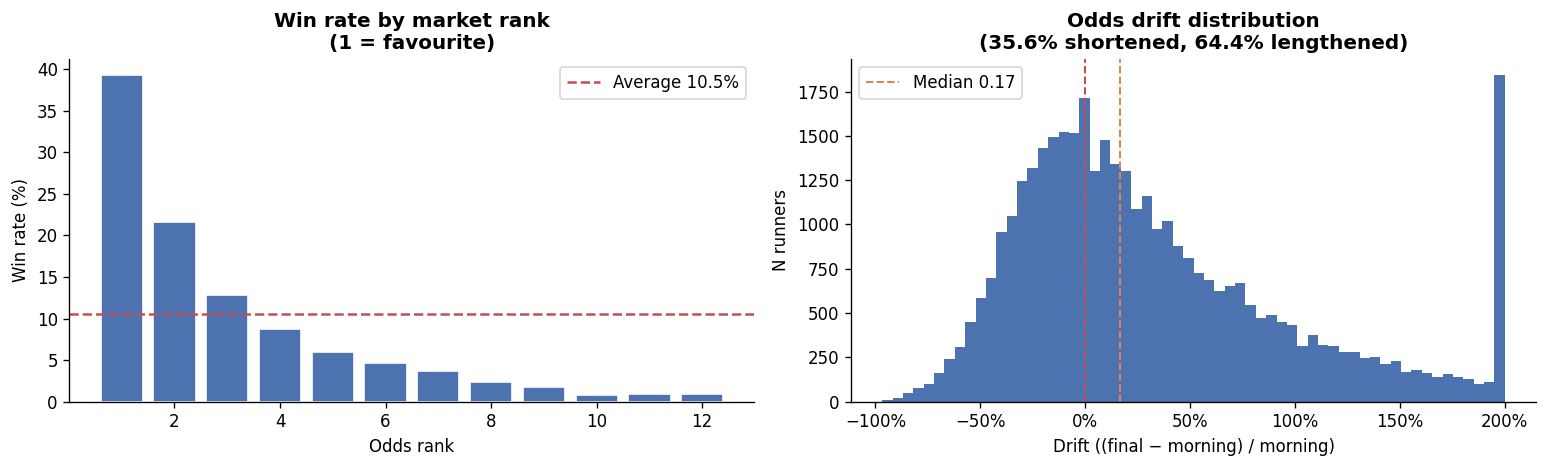

In [8]:
# Favourite win rate by odds rank
rr = race_results.copy()
rr['odds_rank'] = rr.groupby('race_id')['morning_odds'].rank(method='first')
rr['is_winner'] = (rr['finish_position'] == 1).astype(int)

rank_stats = rr.groupby('odds_rank').agg(
    win_rate=('is_winner', 'mean'),
    n=('is_winner', 'count')
).reset_index().query('odds_rank <= 12')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

bars = axes[0].bar(rank_stats['odds_rank'], rank_stats['win_rate'] * 100,
                   color=BLUE, edgecolor='white')
axes[0].axhline(rr['is_winner'].mean() * 100, color=RED, linestyle='--',
                label=f'Average {rr["is_winner"].mean():.1%}')
axes[0].set_title('Win rate by market rank\n(1 = favourite)', fontweight='bold')
axes[0].set_xlabel('Odds rank')
axes[0].set_ylabel('Win rate (%)')
axes[0].legend()

# Odds drift distribution
drift = rr['odds_drift_pct'].dropna().clip(-1, 2)
axes[1].hist(drift, bins=60, color=BLUE, edgecolor='none')
axes[1].axvline(0, color=RED, linewidth=1.2, linestyle='--')
axes[1].axvline(drift.median(), color=ORANGE, linewidth=1.2, linestyle='--',
                label=f'Median {drift.median():.2f}')
shortened = (drift < 0).mean()
axes[1].set_title(f'Odds drift distribution\n({shortened:.1%} shortened, {1-shortened:.1%} lengthened)',
                  fontweight='bold')
axes[1].set_xlabel('Drift ((final − morning) / morning)')
axes[1].set_ylabel('N runners')
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].legend()

plt.tight_layout()
plt.show()

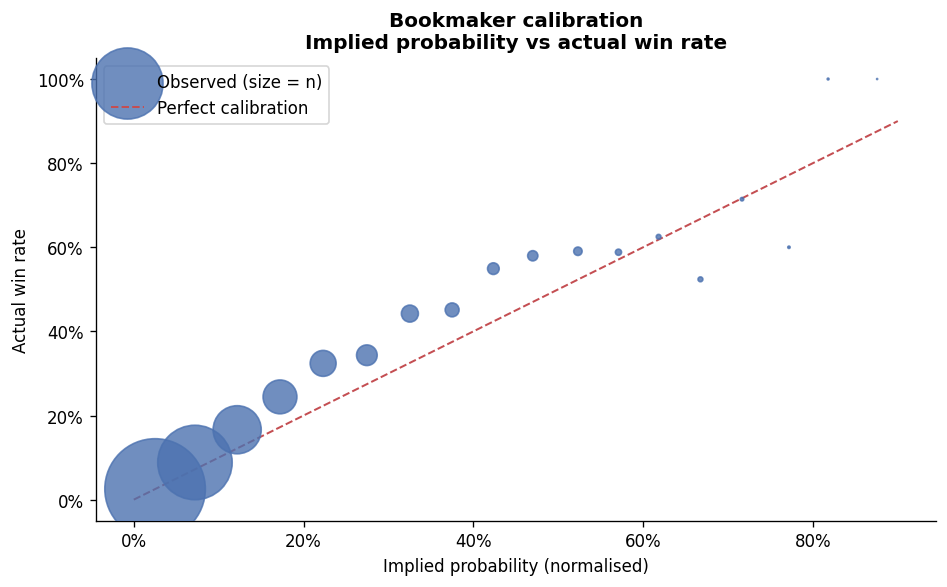

In [9]:
# Market calibration: implied prob vs actual win rate
rr['prob_bin'] = pd.cut(rr['implied_prob_norm'].clip(0, 0.9),
                        bins=np.arange(0, 0.95, 0.05), right=False)
calib = rr.groupby('prob_bin', observed=True).agg(
    actual_win_rate=('is_winner', 'mean'),
    n=('is_winner', 'count'),
    mid=('implied_prob_norm', 'mean')
).dropna()

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(calib['mid'], calib['actual_win_rate'], s=calib['n'] / 5,
           color=BLUE, alpha=0.8, zorder=3, label='Observed (size = n)')
perfect = np.linspace(0, 0.9, 100)
ax.plot(perfect, perfect, color=RED, linestyle='--', linewidth=1.2, label='Perfect calibration')
ax.set_title('Bookmaker calibration\nImplied probability vs actual win rate', fontweight='bold')
ax.set_xlabel('Implied probability (normalised)')
ax.set_ylabel('Actual win rate')
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend()
plt.tight_layout()
plt.show()

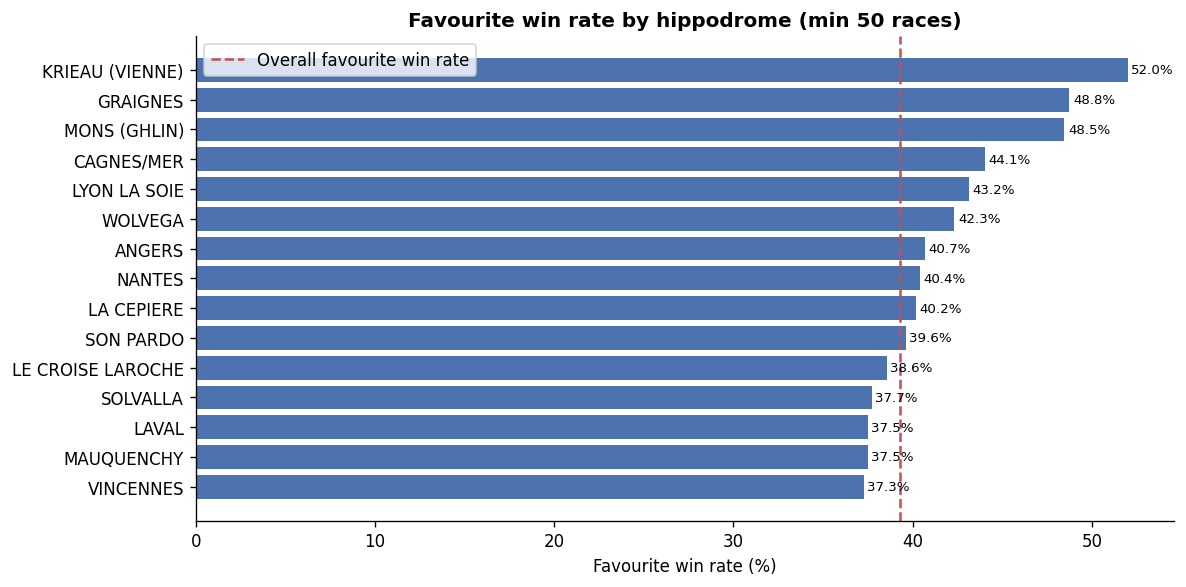

In [10]:
# Win rate by hippodrome (top 15, min 50 races)
hippo_stats = rr.groupby('hippodrome').agg(
    races=('race_id', 'nunique'),
    fav_wins=('is_winner', lambda x: ((rr.loc[x.index, 'odds_rank'] == 1) & (x == 1)).sum()),
).query('races >= 50')
hippo_stats['fav_win_rate'] = hippo_stats['fav_wins'] / hippo_stats['races']
hippo_stats = hippo_stats.sort_values('fav_win_rate', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(hippo_stats.index[::-1], hippo_stats['fav_win_rate'].values[::-1] * 100,
               color=BLUE)
ax.axvline(rr[rr['odds_rank'] == 1]['is_winner'].mean() * 100,
           color=RED, linestyle='--', label='Overall favourite win rate')
for bar, val in zip(bars, hippo_stats['fav_win_rate'].values[::-1]):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height() / 2,
            f'{val:.1%}', va='center', fontsize=8)
ax.set_title('Favourite win rate by hippodrome (min 50 races)', fontweight='bold')
ax.set_xlabel('Favourite win rate (%)')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Form (Musique)

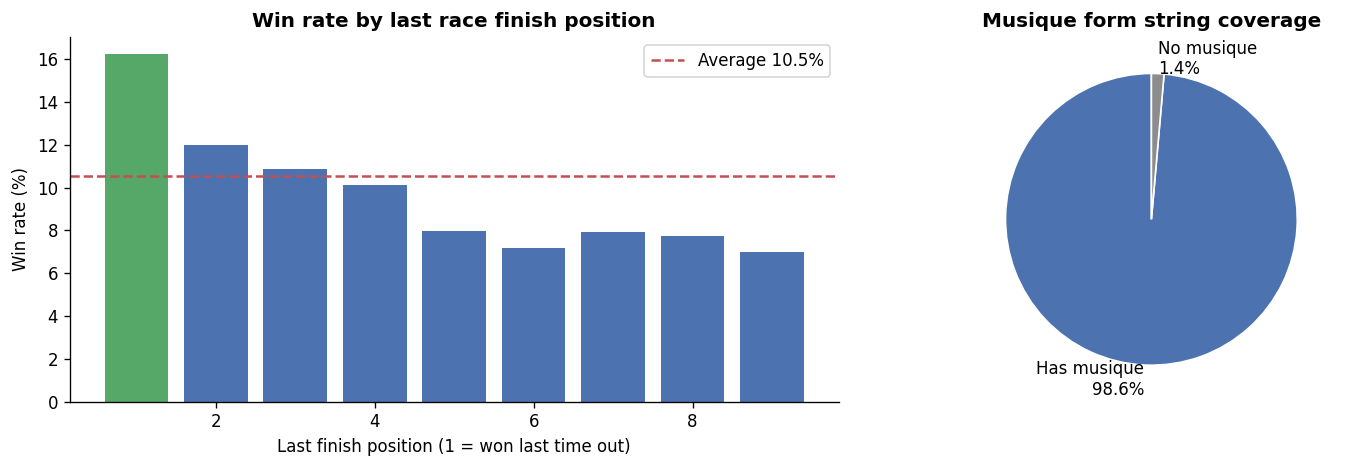

In [11]:
import re

def last_finish(musique: str, n: int = 1) -> float | None:
    """Extract the nth most recent finish position from a musique string.
    Returns NaN for non-numeric results (0=unfinished, D=disq, etc.)."""
    if not isinstance(musique, str) or not musique.strip():
        return np.nan
    tokens = re.findall(r'(\d+|[A-Za-z])', musique)
    numeric = [int(t) for t in tokens if t.isdigit() and int(t) > 0]
    if len(numeric) < n:
        return np.nan
    return float(numeric[-n])  # rightmost = most recent

rr['last1'] = rr['musique'].apply(lambda x: last_finish(x, 1))
rr['last2'] = rr['musique'].apply(lambda x: last_finish(x, 2))

# Win rate by last finish position
form_stats = rr.groupby('last1').agg(
    win_rate=('is_winner', 'mean'),
    n=('is_winner', 'count')
).reset_index().query('last1 <= 15 and n >= 30')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

colors = [GREEN if p == 1 else BLUE for p in form_stats['last1'].astype(int)]
axes[0].bar(form_stats['last1'].astype(int), form_stats['win_rate'] * 100, color=colors)
axes[0].axhline(rr['is_winner'].mean() * 100, color=RED, linestyle='--',
                label=f'Average {rr["is_winner"].mean():.1%}')
axes[0].set_title('Win rate by last race finish position', fontweight='bold')
axes[0].set_xlabel('Last finish position (1 = won last time out)')
axes[0].set_ylabel('Win rate (%)')
axes[0].legend()

# Musique coverage
has_musique = rr['musique'].notna() & (rr['musique'].str.strip() != '')
coverage = has_musique.mean()
axes[1].pie([coverage, 1 - coverage],
            labels=[f'Has musique\n{coverage:.1%}', f'No musique\n{1-coverage:.1%}'],
            colors=[BLUE, GREY], startangle=90, wedgeprops={'edgecolor': 'white'})
axes[1].set_title('Musique form string coverage', fontweight='bold')

plt.tight_layout()
plt.show()

## Summary

In [12]:
fav = rr[rr['odds_rank'] == 1]
margin = odds[odds['odds_type'] == 'morning'].groupby('race_id')['implied_prob'].sum() - 1

print('=' * 55)
print('  DATASET KEY STATISTICS')
print('=' * 55)
print(f'  Races              : {races.race_id.nunique():,}')
print(f'  Hippodromes        : {races.hippodrome.nunique()}')
print(f'  Runners (total)    : {len(runners):,}')
print(f'  Runners (resolved) : {len(rr):,}')
print(f'  Unique horses      : {runners.horse_name.nunique():,}')
print(f'  Unique jockeys     : {runners.jockey_name.nunique():,}')
print(f'  Avg field size     : {races.field_size.mean():.1f} runners')
print(f'  Scratch rate       : {runners.scratch.mean():.1%}')
print()
print(f'  Favourite win rate : {fav["is_winner"].mean():.1%}')
print(f'  Median morning odds: {morning["decimal_odds"].median():.1f}')
print(f'  Median bk margin   : {margin.median():.1%}')
print(f'  Odds shortened     : {(rr["odds_drift_pct"] < 0).mean():.1%}')
print('=' * 55)

  DATASET KEY STATISTICS
  Races              : 4,108
  Hippodromes        : 69
  Runners (total)    : 50,818
  Runners (resolved) : 38,314
  Unique horses      : 14,611
  Unique jockeys     : 2,967
  Avg field size     : 12.4 runners
  Scratch rate       : 2.9%

  Favourite win rate : 39.3%
  Median morning odds: 17.0
  Median bk margin   : 15.8%
  Odds shortened     : 35.3%
